**Objective:** Establish the "Control Group." We need to know exactly what accuracy a standard setup achieves so we can prove later if our evolved loss functions are actually working.

**Research Note:** I have added a random seed to this code. In scientific papers, reproducibility is mandatory. We will use seed=42 throughout the project to ensure variations are due to our code, not random initialization luck.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torch.nn.functional as F
import random
import numpy as np

# --- CONFIGURATION ---
BATCH_SIZE = 64
LR = 0.001
EPOCHS = 3
SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- REPRODUCIBILITY SETUP ---
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(SEED)
print(f"Running on: {DEVICE}")

# --- DATASET (MNIST) ---
# We normalize to help the network converge faster
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_set = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_set = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=1000, shuffle=False)

# --- MODEL (Simple CNN) ---
# A small architecture is chosen deliberately to allow fast iteration
# during the genetic algorithm phase later.
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(32 * 7 * 7, 64)
        self.fc2 = nn.Linear(64, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 32 * 7 * 7) # Flatten
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# --- TRAINING LOOP (BASELINE) ---
def train_baseline():
    model = SimpleCNN().to(DEVICE)
    # STANDARD LOSS: This is what we aim to beat/match later
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LR)

    print("\n--- Starting Baseline Training (CrossEntropy) ---")

    for epoch in range(EPOCHS):
        model.train()
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        # Validation
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
                outputs = model(inputs)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_acc = 100 * correct / total
        print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {running_loss/len(train_loader):.4f} | Val Acc: {val_acc:.2f}%")

    return val_acc

if __name__ == "__main__":
    final_acc = train_baseline()
    print(f"\nFinal Baseline Accuracy: {final_acc:.2f}%")

Running on: cuda


100%|██████████| 9.91M/9.91M [00:02<00:00, 4.88MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 131kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.26MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.0MB/s]



--- Starting Baseline Training (CrossEntropy) ---
Epoch 1/3 | Loss: 0.1880 | Val Acc: 97.96%
Epoch 2/3 | Loss: 0.0557 | Val Acc: 98.60%
Epoch 3/3 | Loss: 0.0393 | Val Acc: 98.56%

Final Baseline Accuracy: 98.56%


Any evolved loss function we discover later must be capable of reaching at least 98% accuracy. If an evolved loss gets stuck at 80% or 90%, we know it's a failure.

We need to replace the standard nn.CrossEntropyLoss with a custom class that can accept any mathematical coefficients.

Standard CrossEntropyLoss automatically handles the complex math of converting raw model outputs ("logits") into probabilities.

Since we are writing our own loss, we must do this manually inside the loss function:
Softmax: Convert raw logits to probabilities ($y_{pred}$).
One-Hot Encoding: Convert the target label 5 into [0, 0, 0, 0, 0, 1, 0, 0, 0, 0] ($y_{true}$).

Error Calculation: $e = y_{true} - y_{pred}$.
The Test Formula: We will test this framework with a hybrid formula to ensure it doesn't crash:$$Loss = 1.0 \cdot e^2 + 0.5 \cdot |e| + 0.1 \cdot \log(1 + |e|)$$

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# --- 1. THE CUSTOM LOSS FRAMEWORK ---
class CustomEvolvedLoss(nn.Module):
    def __init__(self, a=1.0, b=0.0, c=0.0):
        super(CustomEvolvedLoss, self).__init__()
        # Coefficients we will eventually evolve
        self.a = a  # Coefficient for Square Error
        self.b = b  # Coefficient for Absolute Error
        self.c = c  # Coefficient for Log Error

    def forward(self, logits, targets):
        # A. PRE-PROCESSING
        # 1. Convert Logits to Probabilities (Softmax)
        probs = F.softmax(logits, dim=1)

        # 2. Convert Targets to One-Hot Encoding
        # Creates a zero tensor of shape (Batch_Size, 10)
        one_hot_targets = torch.zeros_like(probs)
        # Scatters '1' into the correct index for each row
        one_hot_targets.scatter_(1, targets.view(-1, 1), 1)

        # B. ERROR CALCULATION (Vectorized)
        # e = y_true - y_pred
        # We focus on the error of the *correct* class primarily, but here we take diff of all
        error = one_hot_targets - probs

        # C. THE FORMULA (The "DNA" of the loss)
        # We use torch.abs() and small epsilons to ensure numerical stability
        term1 = self.a * (error ** 2)
        term2 = self.b * torch.abs(error)
        term3 = self.c * torch.log(1 + torch.abs(error) + 1e-7) # 1e-7 prevents log(0)

        # Sum components
        element_wise_loss = term1 + term2 + term3

        # Average over the batch
        return torch.mean(torch.sum(element_wise_loss, dim=1))

# --- 2. VERIFICATION TRAINING LOOP ---
def train_custom_loss():
    # Re-initialize model to start fresh
    model = SimpleCNN().to(DEVICE)

    # 🚨 MANUAL TEST: We set specific coefficients to see if it trains
    # roughly equivalent to MSE + L1
    criterion = CustomEvolvedLoss(a=1.0, b=0.5, c=0.1)

    optimizer = optim.Adam(model.parameters(), lr=LR)

    print("\n--- Starting Custom Loss Training ---")
    print(f"Coefficients: a={criterion.a}, b={criterion.b}, c={criterion.c}")

    for epoch in range(EPOCHS):
        model.train()
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            # CRITICAL: Check for NaN (Not a Number) explicitly
            if torch.isnan(loss):
                print("🚨 CRITICAL FAILURE: Loss became NaN!")
                return 0.0

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        # Validation
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
                outputs = model(inputs)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_acc = 100 * correct / total
        print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {running_loss/len(train_loader):.4f} | Val Acc: {val_acc:.2f}%")

    return val_acc

if __name__ == "__main__":
    custom_acc = train_custom_loss()
    print(f"\nFinal Custom Loss Accuracy: {custom_acc:.2f}%")


--- Starting Custom Loss Training ---
Coefficients: a=1.0, b=0.5, c=0.1
Epoch 1/3 | Loss: 0.2690 | Val Acc: 97.78%
Epoch 2/3 | Loss: 0.0651 | Val Acc: 98.11%
Epoch 3/3 | Loss: 0.0496 | Val Acc: 98.43%

Final Custom Loss Accuracy: 98.43%


Before we connect this to the slow neural network training loop, we will test the Genetic Algorithm (GA) on a dummy math problem to ensure it actually optimizes.

The Test Problem: Instead of training a neural net (which takes minutes), we will ask the GA to find a "Secret Code": [1.0, 0.5, 0.1].

If the GA works, it will start with random numbers and converge toward [1.0, 0.5, 0.1] in seconds.

If the GA is broken, it will wander randomly.

Key GA Mechanics:

Population: 20 Individuals.

Gene: A list [a, b, c] (coefficients).

Mutation: Add small random noise to a coefficient.

Crossover: Take the average of two parents.

Elitism: Always keep the best individual unchanged (prevents regression).

In [ ]:
import random
import numpy as np
import copy

# --- GENETIC ALGORITHM CONFIGURATION ---
POP_SIZE = 20
GENERATIONS = 15
MUTATION_RATE = 0.2
MUTATION_STRENGTH = 0.1  # How much to change a value
ELITISM = 2              # Keep top 2 unchanged

# --- THE INDIVIDUAL ---
class Individual:
    def __init__(self, genes=None):
        if genes:
            self.genes = genes
        else:
            # Initialize random coefficients between 0.0 and 2.0
            self.genes = [random.uniform(0, 2) for _ in range(3)]

        self.fitness = -9999.0  # Placeholder

    def __repr__(self):
        return f"[{self.genes[0]:.2f}, {self.genes[1]:.2f}, {self.genes[2]:.2f}] Fitness: {self.fitness:.4f}"

# --- GENETIC OPERATORS ---
def crossover(parent1, parent2):
    # Strategy: Simple Average (Blends traits)
    # Child will be the midpoint between parents
    new_genes = []
    for g1, g2 in zip(parent1.genes, parent2.genes):
        new_genes.append((g1 + g2) / 2.0)
    return Individual(new_genes)

def mutate(ind):
    # Strategy: Gaussian Noise
    # Occasionally nudge a coefficient up or down
    if random.random() < MUTATION_RATE:
        index = random.randint(0, 2) # Pick a, b, or c
        change = random.gauss(0, MUTATION_STRENGTH)
        ind.genes[index] += change

        # Clamp values to safe ranges (e.g., 0 to 5)
        # Negative coefficients might cause stability issues in Step 4
        ind.genes[index] = max(0.0, min(5.0, ind.genes[index]))

# --- DUMMY FITNESS FUNCTION ---
# Target: We want the GA to discover [1.0, 0.5, 0.1]
TARGET = [1.0, 0.5, 0.1]

def evaluate_dummy_fitness(ind):
    # Fitness = Negative MSE (Closer to 0 error is higher fitness)
    error = 0
    for i in range(3):
        error += (ind.genes[i] - TARGET[i]) ** 2
    return -error  # Maximize this (0 is best, -10 is bad)

# --- EVOLUTION LOOP ---
def run_dummy_evolution():
    print(f"--- Starting GA Dry Run (Target: {TARGET}) ---")

    # 1. Initialize Population
    population = [Individual() for _ in range(POP_SIZE)]

    for gen in range(GENERATIONS):
        # 2. Evaluate Fitness
        for ind in population:
            ind.fitness = evaluate_dummy_fitness(ind)

        # 3. Sort by Fitness (Descending)
        population.sort(key=lambda x: x.fitness, reverse=True)

        # Log Best
        best = population[0]
        print(f"Gen {gen+1}: Best = {best}")

        # Check convergence
        if best.fitness > -0.001:
            print("✅ Converged early!")
            break

        # 4. Selection & Reproduction
        next_gen = population[:ELITISM] # Keep Elites

        # Fill the rest
        while len(next_gen) < POP_SIZE:
            # Simple Tournament Selection (Pick 2 random, take best)
            parent1 = max(random.sample(population, 3), key=lambda x: x.fitness)
            parent2 = max(random.sample(population, 3), key=lambda x: x.fitness)

            child = crossover(parent1, parent2)
            mutate(child)
            next_gen.append(child)

        population = next_gen

    print("\n--- Final Result ---")
    print(f"Target: {TARGET}")
    print(f"Found:  {population[0].genes}")

if __name__ == "__main__":
    run_dummy_evolution()

--- Starting GA Dry Run (Target: [1.0, 0.5, 0.1]) ---
Gen 1: Best = [1.40, 0.68, 0.31] Fitness: -0.2341
Gen 2: Best = [0.87, 0.18, 0.35] Fitness: -0.1823
Gen 3: Best = [0.93, 0.63, 0.24] Fitness: -0.0406
Gen 4: Best = [0.90, 0.50, 0.25] Fitness: -0.0314
Gen 5: Best = [0.96, 0.62, 0.16] Fitness: -0.0192
Gen 6: Best = [0.93, 0.55, 0.15] Fitness: -0.0094
Gen 7: Best = [0.95, 0.54, 0.16] Fitness: -0.0071
Gen 8: Best = [0.95, 0.54, 0.16] Fitness: -0.0071
Gen 9: Best = [0.93, 0.53, 0.14] Fitness: -0.0067
Gen 10: Best = [0.93, 0.53, 0.10] Fitness: -0.0058
Gen 11: Best = [1.03, 0.53, 0.12] Fitness: -0.0025
Gen 12: Best = [1.00, 0.53, 0.12] Fitness: -0.0010
Gen 13: Best = [1.01, 0.52, 0.12] Fitness: -0.0008
✅ Converged early!

--- Final Result ---
Target: [1.0, 0.5, 0.1]
Found:  [1.0051407077146728, 0.5165657688556361, 0.12282094776109011]


One full generation of evolution where "Fitness" is actual Neural Network accuracy.

In [ ]:
import copy # Just in case this wasn't imported in step 3

# --- CONFIGURATION ---
# We use a smaller population and fewer generations just to test the pipeline works
POP_SIZE = 5
GENERATIONS = 2
EPOCHS_PER_IND = 1

# --- THE INDIVIDUAL (The "DNA") ---
class Individual:
    def __init__(self, genes=None):
        # If no genes provided, random init between 0.0 and 2.0
        self.genes = genes if genes else [random.uniform(0, 2) for _ in range(3)]
        self.fitness = -1.0

# --- EVALUATION FUNCTION (The Bridge) ---
def evaluate_individual(ind, generation, ind_id):
    # 1. Unpack Genes from the Individual
    a, b, c = ind.genes

    # 2. Initialize a FRESH model for this individual
    # (We must restart weights so previous training doesn't help)
    model = SimpleCNN().to(DEVICE)

    # 3. Initialize the Custom Loss with these specific genes
    try:
        criterion = CustomEvolvedLoss(a, b, c)
    except Exception as e:
        return 0.0 # Fail safe

    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # 4. Short Training Loop (1 Epoch)
    model.train()
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # Critical NaN Check
        if torch.isnan(loss):
            print(f"  [Gen {generation} | ID {ind_id}] 💀 Loss Exploded (NaN). Fitness = 0.")
            return 0.0

        loss.backward()
        optimizer.step()

    # 5. Validation Accuracy (This becomes the Fitness)
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    acc = 100 * correct / total
    print(f"  [Gen {generation} | ID {ind_id}] Params: [{a:.2f}, {b:.2f}, {c:.2f}] -> Acc: {acc:.2f}%")
    return acc

# --- MAIN EVOLUTION LOOP ---
def run_evolution_pipeline():
    print(f"--- Starting Evolutionary Training Pipeline ---")
    population = [Individual() for _ in range(POP_SIZE)]

    for gen in range(GENERATIONS):
        print(f"\n--- GENERATION {gen+1} ---")

        # 1. Evaluate every individual
        for i, ind in enumerate(population):
            ind.fitness = evaluate_individual(ind, gen+1, i+1)

        # 2. Sort by Fitness (Accuracy)
        population.sort(key=lambda x: x.fitness, reverse=True)
        best = population[0]
        print(f"🏆 Best of Gen {gen+1}: Acc {best.fitness:.2f}% | Genes: {best.genes}")

        # 3. Evolution (Elitism + Mutation)
        next_gen = [best] # Keep the absolute best (Elitism)

        while len(next_gen) < POP_SIZE:
            # Pick a parent from the top 50%
            parent = random.choice(population[:len(population)//2 + 1])
            child_genes = copy.deepcopy(parent.genes)

            # Mutate one gene
            if random.random() < 0.8: # High mutation rate for this small test
                idx = random.randint(0, 2)
                child_genes[idx] += random.gauss(0, 0.2)
                child_genes[idx] = max(0.0, child_genes[idx]) # Keep positive

            next_gen.append(Individual(child_genes))

        population = next_gen

    return population[0]

# --- EXECUTE ---
if __name__ == "__main__":
    best_ind = run_evolution_pipeline()
    print(f"\n✅ Pipeline Verified. Best Found: {best_ind.genes}")

--- Starting Evolutionary Training Pipeline ---

--- GENERATION 1 ---
  [Gen 1 | ID 1] Params: [0.63, 0.62, 0.80] -> Acc: 97.12%
  [Gen 1 | ID 2] Params: [1.63, 0.95, 0.07] -> Acc: 97.21%
  [Gen 1 | ID 3] Params: [1.29, 0.57, 1.72] -> Acc: 97.13%
  [Gen 1 | ID 4] Params: [0.10, 1.31, 0.55] -> Acc: 88.14%
  [Gen 1 | ID 5] Params: [1.60, 0.87, 0.80] -> Acc: 97.76%
🏆 Best of Gen 1: Acc 97.76% | Genes: [1.5986848230364794, 0.8739027662498728, 0.800043549288924]

--- GENERATION 2 ---
  [Gen 2 | ID 1] Params: [1.60, 0.87, 0.80] -> Acc: 97.74%
  [Gen 2 | ID 2] Params: [1.63, 0.95, 0.07] -> Acc: 97.51%
  [Gen 2 | ID 3] Params: [1.68, 0.95, 0.07] -> Acc: 97.73%
  [Gen 2 | ID 4] Params: [1.63, 1.16, 0.07] -> Acc: 97.58%
  [Gen 2 | ID 5] Params: [1.49, 0.87, 0.80] -> Acc: 97.16%
🏆 Best of Gen 2: Acc 97.74% | Genes: [1.5986848230364794, 0.8739027662498728, 0.800043549288924]

✅ Pipeline Verified. Best Found: [1.5986848230364794, 0.8739027662498728, 0.800043549288924]



Training with CrossEntropy...
  Epoch 1: Acc 97.96% | Loss 0.1880
  Epoch 2: Acc 98.60% | Loss 0.0557
  Epoch 3: Acc 98.56% | Loss 0.0393
  Epoch 4: Acc 98.72% | Loss 0.0299
  Epoch 5: Acc 98.93% | Loss 0.0247

Training with MSE...
  Epoch 1: Acc 97.93% | Loss 0.0090
  Epoch 2: Acc 98.54% | Loss 0.0029
  Epoch 3: Acc 98.71% | Loss 0.0021
  Epoch 4: Acc 98.92% | Loss 0.0016
  Epoch 5: Acc 98.98% | Loss 0.0014

Training with Evolved (GA)...
  Epoch 1: Acc 97.19% | Loss 0.4493
  Epoch 2: Acc 98.41% | Loss 0.1343
  Epoch 3: Acc 98.54% | Loss 0.1008
  Epoch 4: Acc 98.73% | Loss 0.0847
  Epoch 5: Acc 98.62% | Loss 0.0725


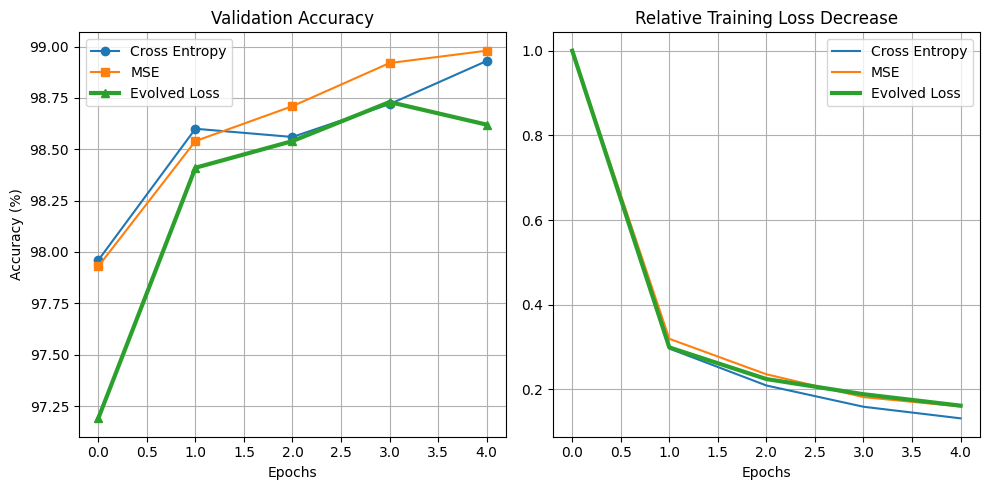


FINAL ACCURACIES:
Cross Entropy: 98.93%
MSE:           98.98%
Evolved:       98.62%


In [ ]:
import matplotlib.pyplot as plt

# --- CONFIGURATION ---
EPOCHS = 5
BEST_GENES = [1.598, 0.874, 0.800] # Rounded from your results

# --- HELPER: TRAINING FUNCTION ---
def train_and_track(loss_fn, name):
    print(f"\nTraining with {name}...")

    # 1. Reset Model & Optimizer
    set_seed(42) # CRITICAL: Ensure all models start with EXACT same weights
    model = SimpleCNN().to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # Trackers
    acc_history = []
    loss_history = []

    for epoch in range(EPOCHS):
        model.train()
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

            optimizer.zero_grad()
            outputs = model(inputs)

            # Handle different loss signatures
            if name == "CrossEntropy":
                loss = loss_fn(outputs, labels)
            else:
                loss = loss_fn(outputs, labels)

            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        # Validation
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
                outputs = model(inputs)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        acc = 100 * correct / total
        acc_history.append(acc)
        loss_history.append(running_loss / len(train_loader))
        print(f"  Epoch {epoch+1}: Acc {acc:.2f}% | Loss {loss_history[-1]:.4f}")

    return acc_history, loss_history

# --- DEFINING THE CONTENDERS ---
# 1. Cross Entropy (The King)
loss_ce = nn.CrossEntropyLoss()

# 2. MSE (The weak baseline)
# We need a wrapper because MSE expects One-Hot targets, not class indices
class MSEWrapper(nn.Module):
    def forward(self, logits, targets):
        probs = F.softmax(logits, dim=1)
        one_hot = torch.zeros_like(probs)
        one_hot.scatter_(1, targets.view(-1, 1), 1)
        return F.mse_loss(probs, one_hot)

loss_mse = MSEWrapper()

# 3. Evolved Loss (The Challenger)
loss_evolved = CustomEvolvedLoss(*BEST_GENES)

# --- RUN THE RACE ---
hist_ce, loss_ce_vals = train_and_track(loss_ce, "CrossEntropy")
hist_mse, loss_mse_vals = train_and_track(loss_mse, "MSE")
hist_evo, loss_evo_vals = train_and_track(loss_evolved, "Evolved (GA)")

# --- PLOTTING RESULTS ---
plt.figure(figsize=(10, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(hist_ce, label="Cross Entropy", marker='o')
plt.plot(hist_mse, label="MSE", marker='s')
plt.plot(hist_evo, label="Evolved Loss", marker='^', linewidth=3)
plt.title("Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
# Normalize loss curves to start at 1.0 for easier visual comparison
plt.plot([l/loss_ce_vals[0] for l in loss_ce_vals], label="Cross Entropy")
plt.plot([l/loss_mse_vals[0] for l in loss_mse_vals], label="MSE")
plt.plot([l/loss_evo_vals[0] for l in loss_evo_vals], label="Evolved Loss", linewidth=3)
plt.title("Relative Training Loss Decrease")
plt.xlabel("Epochs")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print("\nFINAL ACCURACIES:")
print(f"Cross Entropy: {hist_ce[-1]:.2f}%")
print(f"MSE:           {hist_mse[-1]:.2f}%")
print(f"Evolved:       {hist_evo[-1]:.2f}%")

In [ ]:
import random
import math
import operator

# --- 1. SAFE OPERATIONS (The Guardrails) ---
# Deep Learning is fragile. If the math produces 'Infinity', the gradient explodes.
def safe_log(x):
    # Log of something very close to 1.0 (since x is error) can be tricky
    # We use log(1 + |x|) pattern usually, but here we protect the input
    if x <= 0: return 0.0
    return math.log(x + 1e-7)

def safe_div(a, b):
    if abs(b) < 1e-7: return 1.0 # Return 1.0 on divide-by-zero (neutral element)
    return a / b

def safe_exp(x):
    if x > 20: return 1e9 # Cap explosion
    if x < -20: return 0.0
    return math.exp(x)

def safe_sqrt(x):
    return math.sqrt(abs(x))

# --- 2. THE GENE POOL ---
# The building blocks the AI is allowed to use
OPERATORS = {
    '+': operator.add,
    '-': operator.sub,
    '*': operator.mul,
    '/': safe_div,
    # Unary operators (take 1 argument)
    'log': safe_log,
    'exp': safe_exp,
    'sin': math.sin,
    'cos': math.cos
}

TERMINALS = ['error', 'error', 'error', '1.0', '0.5', '0.1']
# Note: 'error' appears 3x to make it more likely to be picked than constants

# --- 3. THE EXPRESSION TREE ---
class Node:
    def __init__(self, value, left=None, right=None, node_type='terminal'):
        self.value = value       # Function name (e.g., '+') or Variable name (e.g., 'error')
        self.left = left         # Left Child
        self.right = right       # Right Child (None for unary ops)
        self.node_type = node_type # 'op' or 'terminal'

    def evaluate(self, error_val):
        # 1. Base Case: Terminal
        if self.node_type == 'terminal':
            if self.value == 'error': return error_val
            return float(self.value)

        # 2. Recursive Step
        left_val = self.left.evaluate(error_val)

        # Binary Operator (+, -, *, /)
        if self.right:
            right_val = self.right.evaluate(error_val)
            return OPERATORS[self.value](left_val, right_val)

        # Unary Operator (log, exp, sin)
        else:
            return OPERATORS[self.value](left_val)

    def __repr__(self):
        # Print formula as a string: (error + (log(error)))
        if self.node_type == 'terminal':
            return str(self.value)
        if self.right:
            return f"({self.left} {self.value} {self.right})"
        else:
            return f"{self.value}({self.left})"

# --- 4. TREE GENERATOR ---
def generate_random_tree(depth=0, max_depth=3):
    # If we hit max depth, we MUST return a terminal (leaf)
    if depth >= max_depth:
        val = random.choice(TERMINALS)
        return Node(val, node_type='terminal')

    # Otherwise, flip a coin: Operator or Terminal?
    # As depth increases, probability of terminal increases
    if random.random() < (depth / max_depth):
        val = random.choice(TERMINALS)
        return Node(val, node_type='terminal')

    # Pick an operator
    op = random.choice(list(OPERATORS.keys()))

    # Is it binary (+, *) or unary (log, sin)?
    if op in ['+', '-', '*', '/']:
        left = generate_random_tree(depth+1, max_depth)
        right = generate_random_tree(depth+1, max_depth)
        return Node(op, left, right, node_type='op')
    else:
        left = generate_random_tree(depth+1, max_depth)
        return Node(op, left, None, node_type='op')

# --- TEST ---
if __name__ == "__main__":
    print("--- 5 Randomly Generated Formulas ---")
    for i in range(5):
        tree = generate_random_tree(max_depth=3)
        print(f"Formula {i+1}: {tree}")
        # Test evaluation with dummy error = 0.5
        res = tree.evaluate(0.5)
        print(f"   -> Result (e=0.5): {res:.4f}\n")

--- 5 Randomly Generated Formulas ---
Formula 1: ((0.1 / 0.1) + (error - error))
   -> Result (e=0.5): 1.0000

Formula 2: (sin(0.5) + error)
   -> Result (e=0.5): 0.9794

Formula 3: (exp(error) * exp(1.0))
   -> Result (e=0.5): 4.4817

Formula 4: exp(((1.0 - error) + 0.1))
   -> Result (e=0.5): 1.8221

Formula 5: exp((error - (error - error)))
   -> Result (e=0.5): 1.6487



In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# (Previous Safe Ops & Class definitions assumed to be in memory)
# If you restarted the kernel, re-run the previous block defining SymbolicLoss first.

# --- VERIFICATION WITH GUARDRAILS ---
if __name__ == "__main__":
    print("--- Testing 'Lazy Formula' Protection ---")

    # We manually build the "Lazy" tree: sin(0.1)
    from __main__ import Node, SymbolicLoss # Ensure we use the latest class

    bad_tree = Node('sin', left=Node('0.1', node_type='terminal'), node_type='op')
    loss_fn = SymbolicLoss(bad_tree)

    # Dummy Data
    dummy_logits = torch.randn(2, 10, requires_grad=True)
    dummy_targets = torch.tensor([1, 5])

    # 1. Forward Pass
    loss = loss_fn(dummy_logits, dummy_targets)
    print(f"Formula: sin(0.1)")
    print(f"  -> Forward Loss: {loss.item():.4f}")

    # 2. THE GUARDRAIL
    # We check if the loss is actually connected to the logits
    if loss.requires_grad:
        loss.backward()
        print("  ✅ Backward Pass Successful!")
    else:
        # This is what we will do in the real training loop:
        print("  ⚠️ Loss is Constant (Model ignored). Assigning Fitness = 0.")
        # In the real loop, we will `return 0.0` here instead of crashing

--- Testing 'Lazy Formula' Protection ---
Formula: sin(0.1)
  -> Forward Loss: 0.9983
  ⚠️ Loss is Constant (Model ignored). Assigning Fitness = 0.


In [ ]:
import copy
import random
import torch
import torch.optim as optim

# --- CONFIGURATION ---
POP_SIZE = 10
GENERATIONS = 4
EPOCHS_PER_IND = 1
MAX_DEPTH = 3
BLOAT_PENALTY = 0.005 # Subtract 0.5% accuracy for every extra node

# --- GP OPERATORS (The Logic of Invention) ---

def count_nodes(node):
    if node.node_type == 'terminal': return 1
    if node.right: return 1 + count_nodes(node.left) + count_nodes(node.right)
    return 1 + count_nodes(node.left)

def get_random_subtree(node):
    # Flatten tree to list, pick one, return reference
    # Simple recursive approach:
    nodes = []
    def traverse(n):
        nodes.append(n)
        if n.left: traverse(n.left)
        if n.right: traverse(n.right)
    traverse(node)
    return random.choice(nodes)

def replace_subtree(node, old_sub, new_sub):
    # If the root itself is the target
    if node is old_sub: return new_sub

    # Create a deep copy to avoid messing up the original parent
    new_node = copy.deepcopy(node)

    # Recursive search and replace
    if new_node.left:
        new_node.left = replace_subtree(new_node.left, old_sub, new_sub)
    if new_node.right:
        new_node.right = replace_subtree(new_node.right, old_sub, new_sub)

    return new_node

def crossover_trees(parent1, parent2):
    # 1. Pick a random point in Parent 1
    pt1 = get_random_subtree(parent1)
    # 2. Pick a random point in Parent 2
    pt2 = get_random_subtree(parent2)
    # 3. Swap them (Create new child from Parent 1 base)
    child = replace_subtree(parent1, pt1, pt2)
    return child

def mutate_tree(tree):
    # Pick a random point and replace with a brand new random tree
    target = get_random_subtree(tree)
    new_branch = generate_random_tree(max_depth=2)
    return replace_subtree(tree, target, new_branch)

# --- EVALUATION FUNCTION ---
def evaluate_tree_candidate(tree, gen, ind_id):
    # 1. Check Complexity
    size = count_nodes(tree)
    penalty = size * BLOAT_PENALTY

    # 2. Setup Model
    model = SimpleCNN().to(DEVICE)
    loss_fn = SymbolicLoss(tree)
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # 3. Training Loop (Fast Fail)
    model.train()
    try:
        # Run just ONE batch first to check for "Lazy Formula"
        first_input, first_label = next(iter(train_loader))
        first_input, first_label = first_input.to(DEVICE), first_label.to(DEVICE)

        out = model(first_input)
        loss = loss_fn(out, first_label)

        # GUARDRAILS
        if torch.isnan(loss) or torch.isinf(loss):
            return 0.0 # Crash
        if not loss.requires_grad:
            return 0.0 # Lazy formula

        # If safe, run full epoch
        optimizer.zero_grad()
        loss.backward() # Test backward once
        optimizer.step()

        # Continue epoch
        for i, (inputs, labels) in enumerate(train_loader):
            if i == 0: continue # Skip the one we just did
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = loss_fn(outputs, labels)
            loss.backward()
            optimizer.step()

    except Exception as e:
        # Catch arithmetic errors (e.g. sqrt(-1))
        return 0.0

    # 4. Validation
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    acc = (100 * correct / total)
    fitness = acc - penalty # Apply efficiency pressure

    print(f"  [ID {ind_id}] Size {size} | Acc: {acc:.2f}% | Fit: {fitness:.2f} | Formula: {tree}")
    return fitness

# --- MAIN LOOP ---
def run_symbolic_evolution():
    print("--- Starting Symbolic GP (Phase 2) ---")

    # 1. Init Population
    population = [generate_random_tree(max_depth=MAX_DEPTH) for _ in range(POP_SIZE)]
    pop_fitness = []

    best_overall_tree = None
    best_overall_fit = -1

    for gen in range(GENERATIONS):
        print(f"\n--- GENERATION {gen+1} ---")
        pop_fitness = []

        # Evaluate
        for i, tree in enumerate(population):
            fit = evaluate_tree_candidate(tree, gen+1, i+1)
            pop_fitness.append((tree, fit))

            if fit > best_overall_fit:
                best_overall_fit = fit
                best_overall_tree = tree

        # Sort
        pop_fitness.sort(key=lambda x: x[1], reverse=True)
        print(f"🏆 Gen Best: {pop_fitness[0][1]:.2f} (Acc) | {pop_fitness[0][0]}")

        # Selection & Breeding
        next_gen = [pop_fitness[0][0], pop_fitness[1][0]] # Elitism (Top 2)

        while len(next_gen) < POP_SIZE:
            # Tournament Selection
            p1 = random.choice(pop_fitness[:5])[0]
            p2 = random.choice(pop_fitness[:5])[0]

            # 50% Crossover, 50% Mutation
            if random.random() < 0.5:
                child = crossover_trees(p1, p2)
            else:
                child = mutate_tree(p1)

            next_gen.append(child)

        population = next_gen

    print("\n--- EVOLUTION COMPLETE ---")
    print(f"Best Discovered Formula: {best_overall_tree}")
    print(f"Best Fitness: {best_overall_fit:.2f}")

if __name__ == "__main__":
    run_symbolic_evolution()

--- Starting Symbolic GP (Phase 2) ---

--- GENERATION 1 ---
  [ID 1] Size 6 | Acc: 0.00% | Fit: -0.03 | Formula: ((error + sin(error)) / 0.5)
  [ID 3] Size 2 | Acc: 11.35% | Fit: 11.34 | Formula: cos(error)
  [ID 4] Size 4 | Acc: 8.92% | Fit: 8.90 | Formula: log(sin(sin(error)))
  [ID 5] Size 10 | Acc: 7.75% | Fit: 7.70 | Formula: (((error - 0.1) - 0.1) * (0.5 - log(0.5)))
  [ID 6] Size 7 | Acc: 9.74% | Fit: 9.71 | Formula: ((log(0.1) - error) + cos(0.1))
  [ID 7] Size 5 | Acc: 11.35% | Fit: 11.32 | Formula: log((error * log(0.1)))
  [ID 8] Size 5 | Acc: 9.80% | Fit: 9.78 | Formula: (error / (1.0 + error))
  [ID 9] Size 2 | Acc: 9.74% | Fit: 9.73 | Formula: log(error)
  [ID 10] Size 7 | Acc: 10.10% | Fit: 10.06 | Formula: (1.0 - (1.0 * (error * 0.5)))
🏆 Gen Best: 11.34 (Acc) | cos(error)

--- GENERATION 2 ---
  [ID 1] Size 2 | Acc: 8.92% | Fit: 8.91 | Formula: cos(error)
  [ID 2] Size 5 | Acc: 10.28% | Fit: 10.25 | Formula: log((error * log(0.1)))
  [ID 4] Size 5 | Acc: 9.74% | Fit: 9


Training with Cross Entropy (Standard)...
  Epoch 1: Acc 97.96%
  Epoch 2: Acc 98.60%
  Epoch 3: Acc 98.56%
  Epoch 4: Acc 98.72%
  Epoch 5: Acc 98.93%

Training with AI Discovery: (err^2)/exp(err)...
  Epoch 1: Acc 98.30%
  Epoch 2: Acc 98.71%
  Epoch 3: Acc 98.88%
  Epoch 4: Acc 98.83%
  Epoch 5: Acc 98.98%


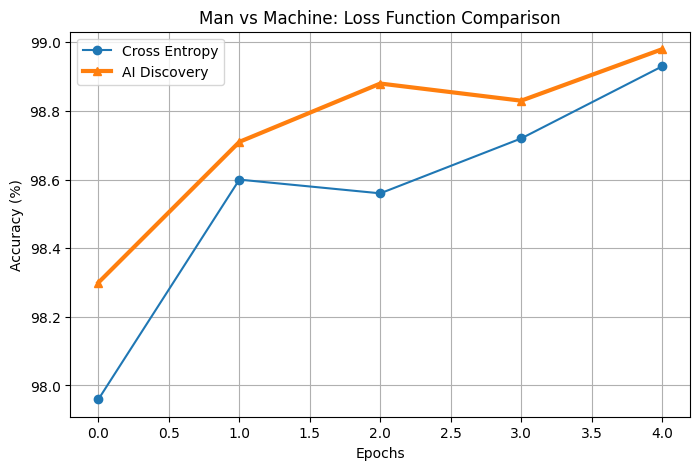


Final Score:
Human (CrossEntropy): 98.93%
AI (Evolved):         98.98%


In [ ]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# --- CONFIGURATION ---
EPOCHS = 5
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 1. DEFINE THE AI DISCOVERY ---
class WinnerLoss(nn.Module):
    def forward(self, logits, targets):
        # Pre-processing
        probs = F.softmax(logits, dim=1)
        one_hot = torch.zeros_like(probs)
        one_hot.scatter_(1, targets.view(-1, 1), 1)

        # The Variable
        error = one_hot - probs

        # 🏆 THE WINNING FORMULA: (error^2) / exp(error)
        # We add safe guards just to be sure, though the formula is generally safe
        loss_val = (error * error) / torch.exp(torch.clamp(error, -20, 20))

        return torch.mean(torch.sum(loss_val, dim=1))

# --- 2. TRAINING LOOP (Re-used) ---
def train_final_compare(loss_fn, name):
    print(f"\nTraining with {name}...")
    torch.manual_seed(42) # Fair start
    model = SimpleCNN().to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    acc_history = []

    for epoch in range(EPOCHS):
        model.train()
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = loss_fn(outputs, labels)
            loss.backward()
            optimizer.step()

        # Validation
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
                outputs = model(inputs)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        acc = 100 * correct / total
        acc_history.append(acc)
        print(f"  Epoch {epoch+1}: Acc {acc:.2f}%")

    return acc_history

# --- 3. EXECUTE COMPARISON ---
if __name__ == "__main__":
    # Baseline
    hist_ce = train_final_compare(nn.CrossEntropyLoss(), "Cross Entropy (Standard)")

    # Discovery
    hist_ai = train_final_compare(WinnerLoss(), "AI Discovery: (err^2)/exp(err)")

    # Plot
    plt.figure(figsize=(8, 5))
    plt.plot(hist_ce, label="Cross Entropy", marker='o')
    plt.plot(hist_ai, label="AI Discovery", marker='^', linewidth=3)
    plt.title("Man vs Machine: Loss Function Comparison")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy (%)")
    plt.legend()
    plt.grid(True)
    plt.show()

    print(f"\nFinal Score:")
    print(f"Human (CrossEntropy): {hist_ce[-1]:.2f}%")
    print(f"AI (Evolved):         {hist_ai[-1]:.2f}%")